# 03 | Applications

This notebook focuses on the main project questions:

- Which profiles concentrate high ratings?
- Which profiles concentrate low ratings?
- How does the concentration story connect back to the popularity/prestige features from the first study?


## Setup

This notebook depends on two analysis stages:

- the **rating-extremes stage**
- the **feature-alignment stage**

If the required artifacts are missing, it rebuilds them in sequence.


In [1]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "rec_dating_project").exists():
            return candidate
    raise RuntimeError("Could not locate the project root from the current working directory.")


project_root = locate_project_root()
sys.path.insert(0, str(project_root / "src"))

from rec_dating_project import ProjectPaths


paths = ProjectPaths.default()
paths.ensure_output_dirs()
OUTPUT_DATA = paths.output_data_dir
OUTPUT_FIGURES = paths.output_figures_dir
FORCE_REBUILD = False


def run_script(script_name: str, *args: str) -> None:
    cmd = [sys.executable, str(paths.scripts_dir / script_name), *args]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=paths.project_root)


def ensure_stage_two_outputs(force: bool = False) -> None:
    required = [
        OUTPUT_DATA / "profile_metrics_full.csv",
        OUTPUT_DATA / "profile_metrics_positive_8_full.csv",
        OUTPUT_DATA / "rater_metrics_full.csv",
    ]
    if force or any(not path.exists() for path in required):
        run_script("02_full_project_analysis.py")


def ensure_stage_three_outputs(force: bool = False) -> None:
    ensure_stage_two_outputs(force=force)

    extremes_required = [
        OUTPUT_DATA / "profile_rating_extremes_summary_full.csv",
        OUTPUT_DATA / "profile_rating_extremes_buckets_full.csv",
        OUTPUT_DATA / "profile_rating_extremes_profiles_full.csv",
        OUTPUT_DATA / "top_profiles_high_ratings_full.csv",
        OUTPUT_DATA / "top_profiles_low_ratings_full.csv",
        OUTPUT_FIGURES / "profile_high_low_rating_concentration_full.png",
        OUTPUT_FIGURES / "profile_rating_concentration_curves_full.png",
        OUTPUT_FIGURES / "profile_bucket_shares_full.png",
        OUTPUT_FIGURES / "profile_interaction_concentration_curve_full.png",
        OUTPUT_FIGURES / "profile_interaction_bucket_shares_full.png",
    ]
    if force or any(not path.exists() for path in extremes_required):
        run_script("03_profile_rating_extremes.py")

    alignment_required = [
        OUTPUT_DATA / "profile_feature_alignment_summary_full.csv",
        OUTPUT_DATA / "profile_feature_alignment_overlap_full.csv",
        OUTPUT_DATA / "profile_feature_alignment_correlations_full.csv",
        OUTPUT_DATA / "profile_feature_alignment_profiles_full.csv",
        OUTPUT_DATA / "profile_feature_alignment_feature_classes_full.csv",
        OUTPUT_FIGURES / "profile_feature_alignment_heatmap_full.png",
        OUTPUT_FIGURES / "profile_feature_alignment_zscore_heatmap_full.png",
        OUTPUT_FIGURES / "profile_feature_alignment_consistency_full.png",
    ]
    if force or any(not path.exists() for path in alignment_required):
        run_script("04_profile_feature_alignment.py")


ensure_stage_three_outputs(FORCE_REBUILD)

extreme_summary = pd.read_csv(OUTPUT_DATA / "profile_rating_extremes_summary_full.csv")
extreme_buckets = pd.read_csv(OUTPUT_DATA / "profile_rating_extremes_buckets_full.csv")
top_high = pd.read_csv(OUTPUT_DATA / "top_profiles_high_ratings_full.csv")
top_low = pd.read_csv(OUTPUT_DATA / "top_profiles_low_ratings_full.csv")

alignment_summary = pd.read_csv(OUTPUT_DATA / "profile_feature_alignment_summary_full.csv")
alignment_overlap = pd.read_csv(OUTPUT_DATA / "profile_feature_alignment_overlap_full.csv")
alignment_correlations = pd.read_csv(OUTPUT_DATA / "profile_feature_alignment_correlations_full.csv")
alignment_profiles = pd.read_csv(OUTPUT_DATA / "profile_feature_alignment_profiles_full.csv")
alignment_feature_classes = pd.read_csv(OUTPUT_DATA / "profile_feature_alignment_feature_classes_full.csv")

all_summary = extreme_summary.loc[extreme_summary["series"] == "all_interactions"].iloc[0]
high_summary = extreme_summary.loc[extreme_summary["series"] == "high_ratings"].iloc[0]
low_summary = extreme_summary.loc[extreme_summary["series"] == "low_ratings"].iloc[0]

bucket_order = ["Top 1%", "Top 1-5%", "Top 5-10%", "Top 10-20%", "Top 20-50%", "Bottom 50%"]
rating_bucket_view = (
    extreme_buckets.pivot(index="bucket", columns="series", values="value_share")
    .reindex(bucket_order)
    .rename(columns={"high_ratings": "high_ratings_share", "low_ratings": "low_ratings_share"})
    [["high_ratings_share", "low_ratings_share"]]
    .reset_index()
)
interaction_bucket_view = (
    extreme_buckets.loc[extreme_buckets["series"] == "all_interactions", ["bucket", "value_share"]]
    .rename(columns={"value_share": "all_interactions_share"})
    .set_index("bucket")
    .reindex(bucket_order)
    .reset_index()
)


## Application 1 | Rating Extremes and Interaction Concentration

We start with the profile side:

- overall interaction concentration
- high-rating concentration
- low-rating concentration

This tells us whether the same small subset of profiles dominates multiple kinds of received attention.


In [2]:
concentration_summary = pd.DataFrame(
    [
        {"series": "all_interactions", "top_1pct_share": all_summary["top_1pct_share"], "top_10pct_share": all_summary["top_10pct_share"], "top_20pct_share": all_summary["top_20pct_share"], "user_share_for_80pct": all_summary["user_share_for_80pct"]},
        {"series": "high_ratings", "top_1pct_share": high_summary["top_1pct_share"], "top_10pct_share": high_summary["top_10pct_share"], "top_20pct_share": high_summary["top_20pct_share"], "user_share_for_80pct": high_summary["user_share_for_80pct"]},
        {"series": "low_ratings", "top_1pct_share": low_summary["top_1pct_share"], "top_10pct_share": low_summary["top_10pct_share"], "top_20pct_share": low_summary["top_20pct_share"], "user_share_for_80pct": low_summary["user_share_for_80pct"]},
    ]
)

display(concentration_summary)
display(rating_bucket_view)
display(interaction_bucket_view)


,series,top_1pct_share,top_10pct_share,top_20pct_share,user_share_for_80pct
0,all_interactions,0.2823,0.6893,0.8391,0.1657
1,high_ratings,0.4375,0.8114,0.9082,0.0930
2,low_ratings,0.2775,0.7558,0.8976,0.1217


series,bucket,high_ratings_share,low_ratings_share
0,Top 1%,0.4374,0.2774
1,Top 1-5%,0.2612,0.3135
2,Top 5-10%,0.1128,0.1649
3,Top 10-20%,0.0968,0.1419
4,Top 20-50%,0.0775,0.0945
5,Bottom 50%,0.0143,0.0078


,bucket,all_interactions_share
0,Top 1%,0.2822
1,Top 1-5%,0.2592
2,Top 5-10%,0.1478
3,Top 10-20%,0.1498
4,Top 20-50%,0.1384
5,Bottom 50%,0.0225


### profile_high_low_rating_concentration_full.png

Cumulative concentration of high and low ratings.

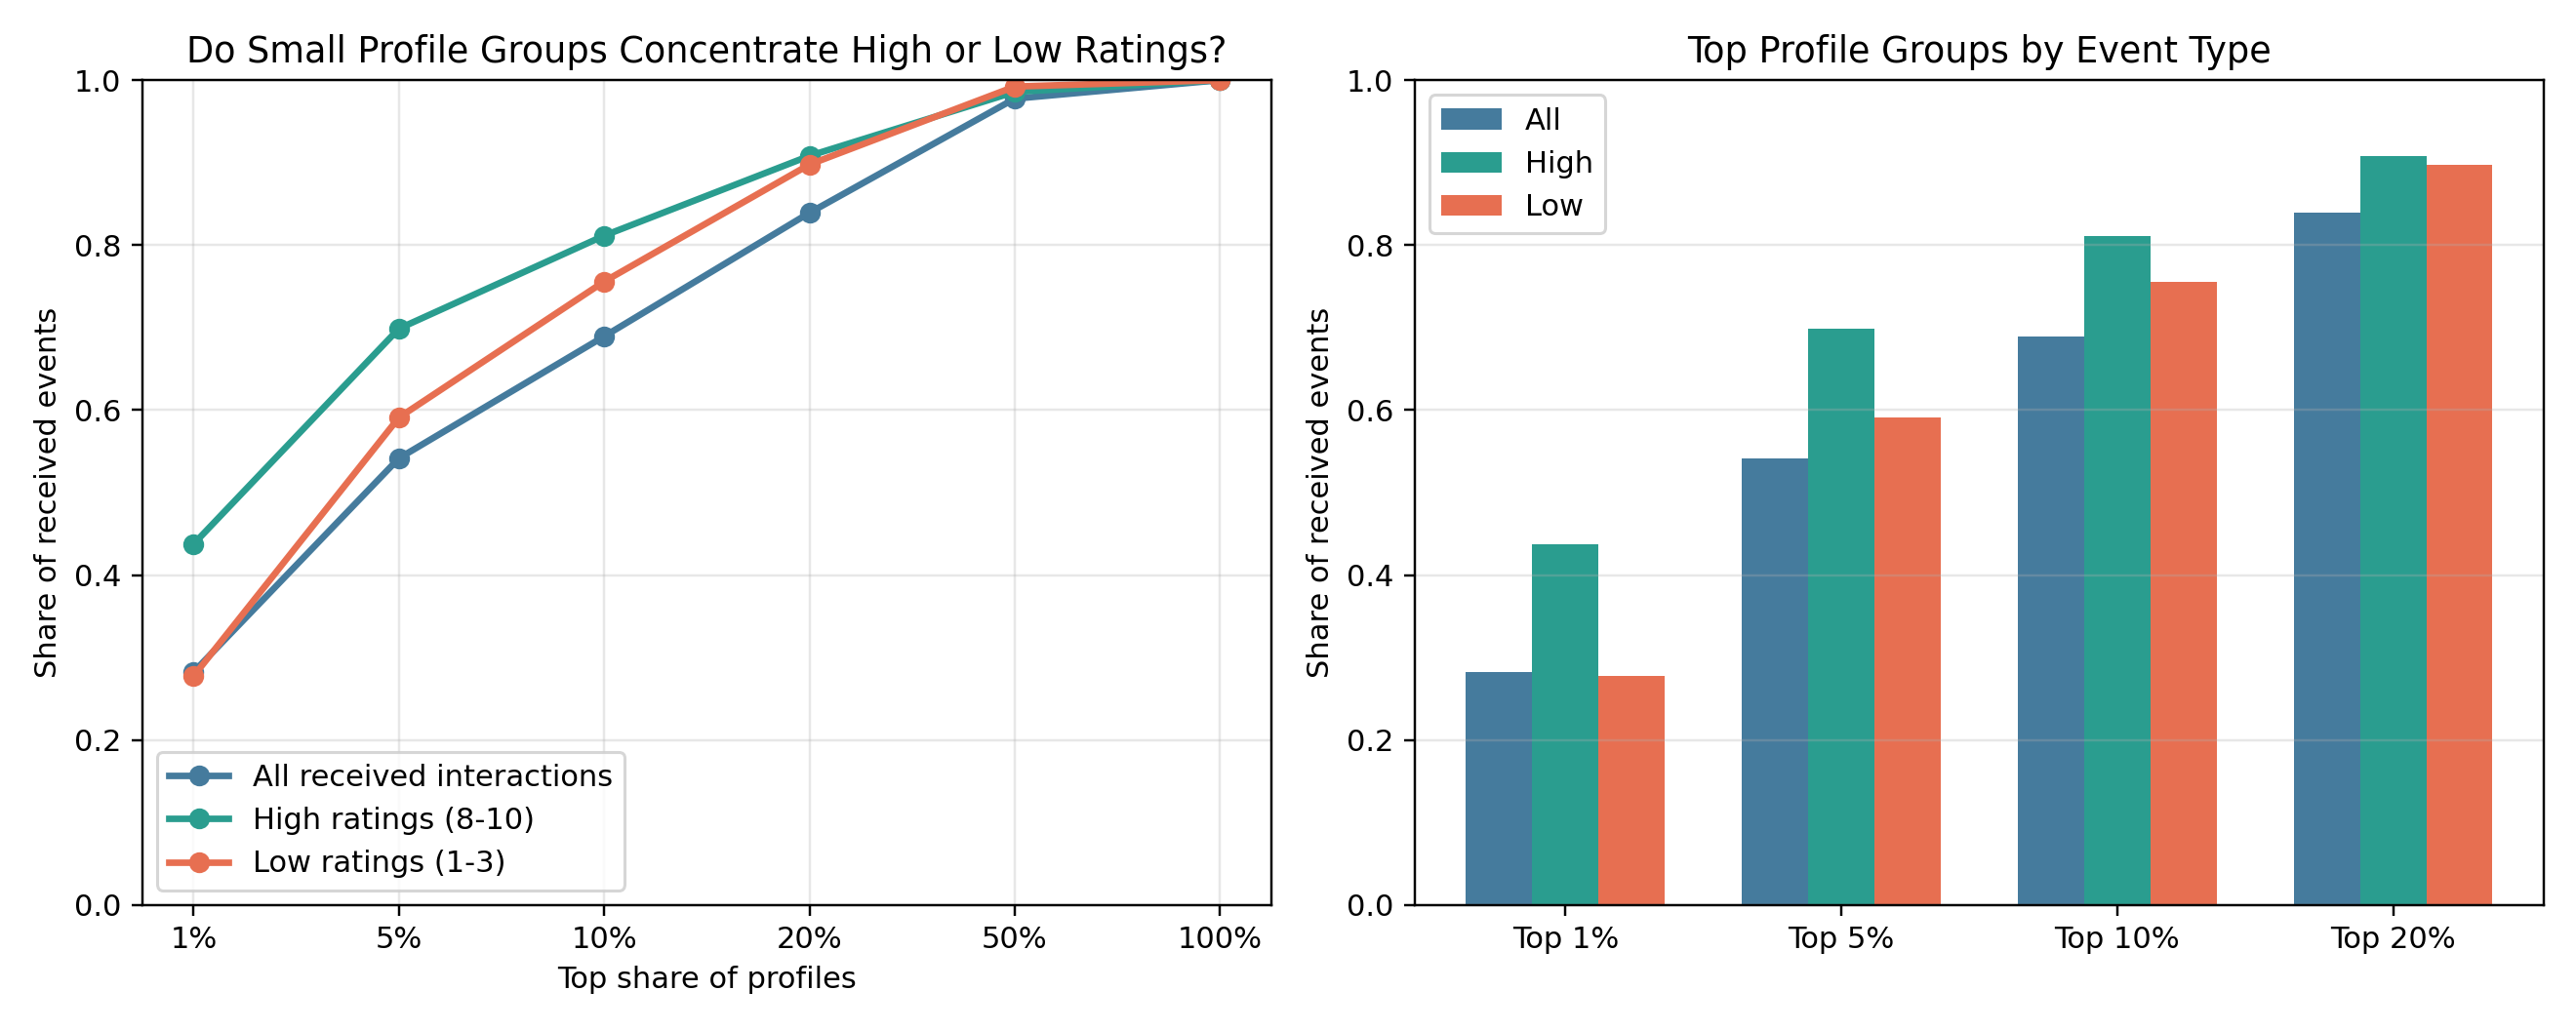

### profile_rating_concentration_curves_full.png

Separate concentration curves for high and low ratings.

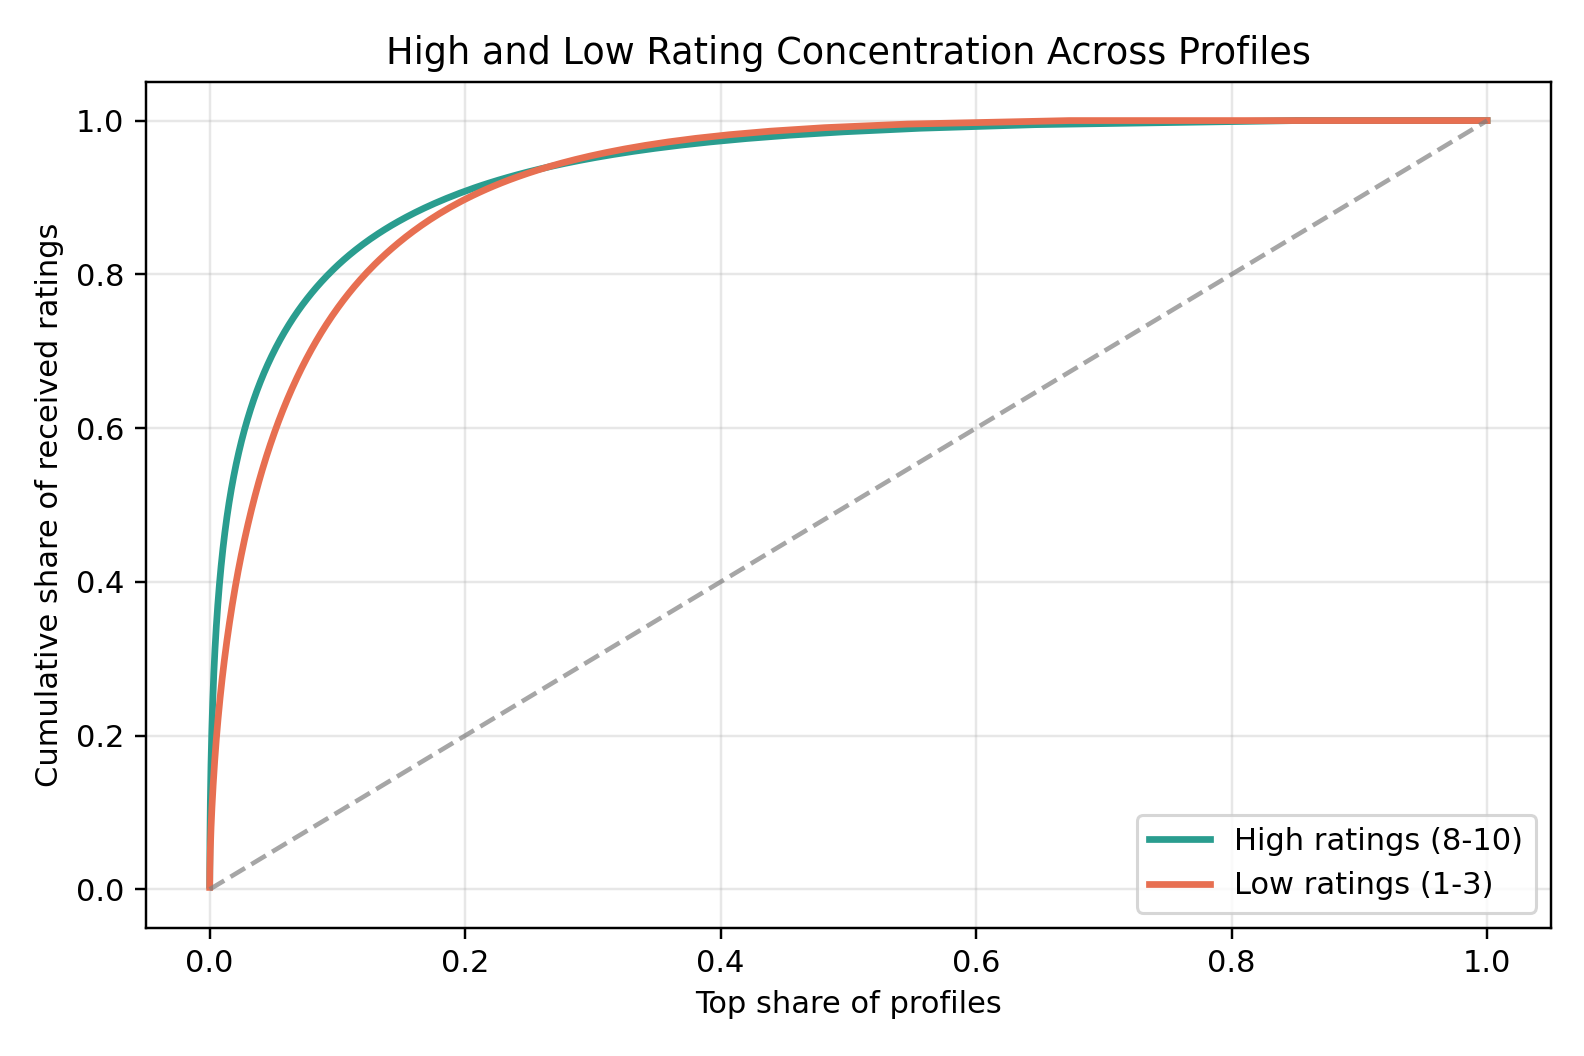

### profile_bucket_shares_full.png

Disjoint bucket shares for high and low ratings.

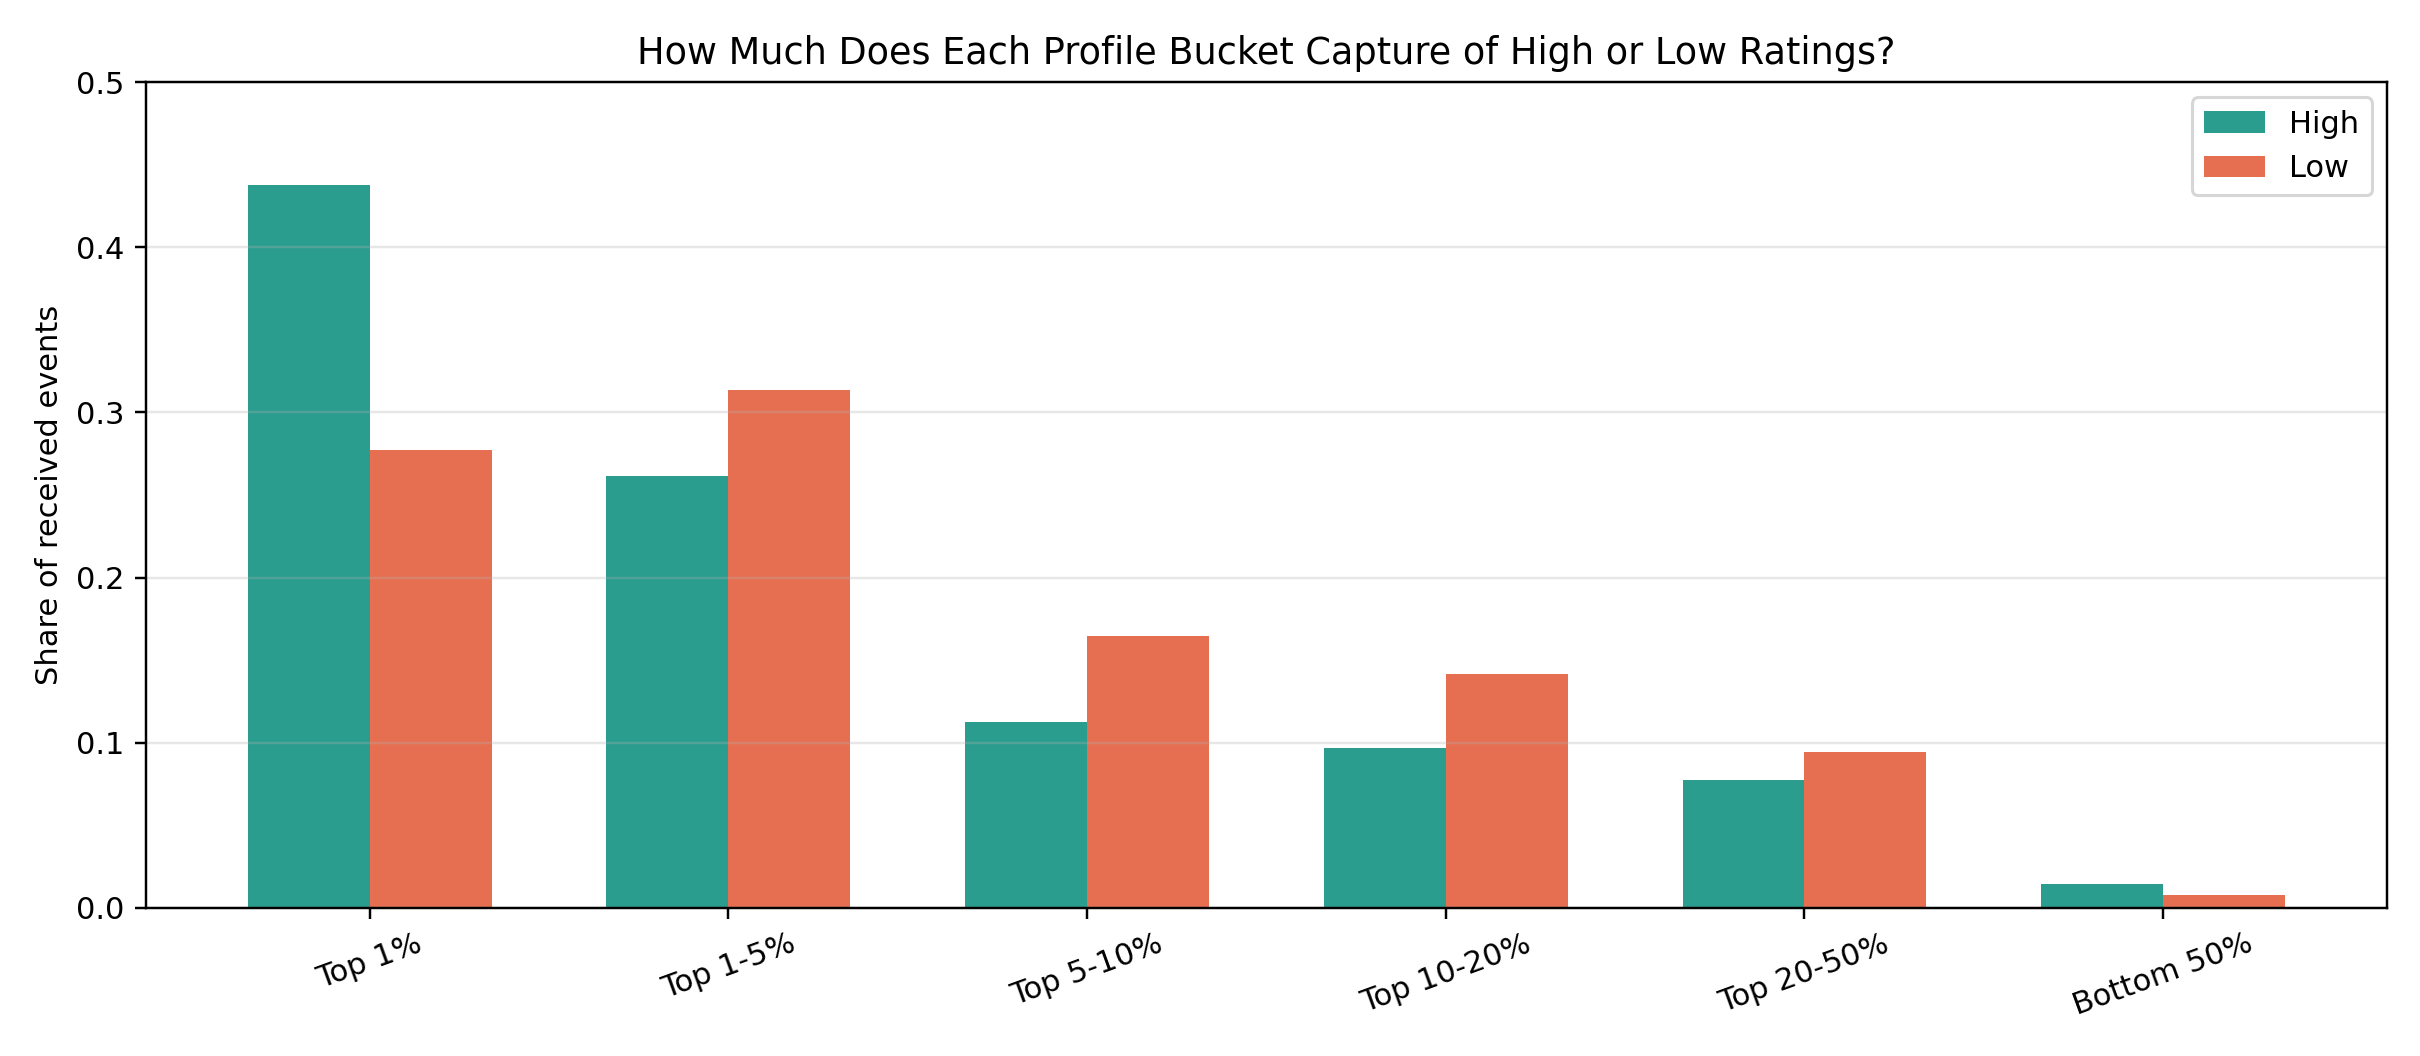

### profile_interaction_concentration_curve_full.png

Overall interaction concentration on the profile side.

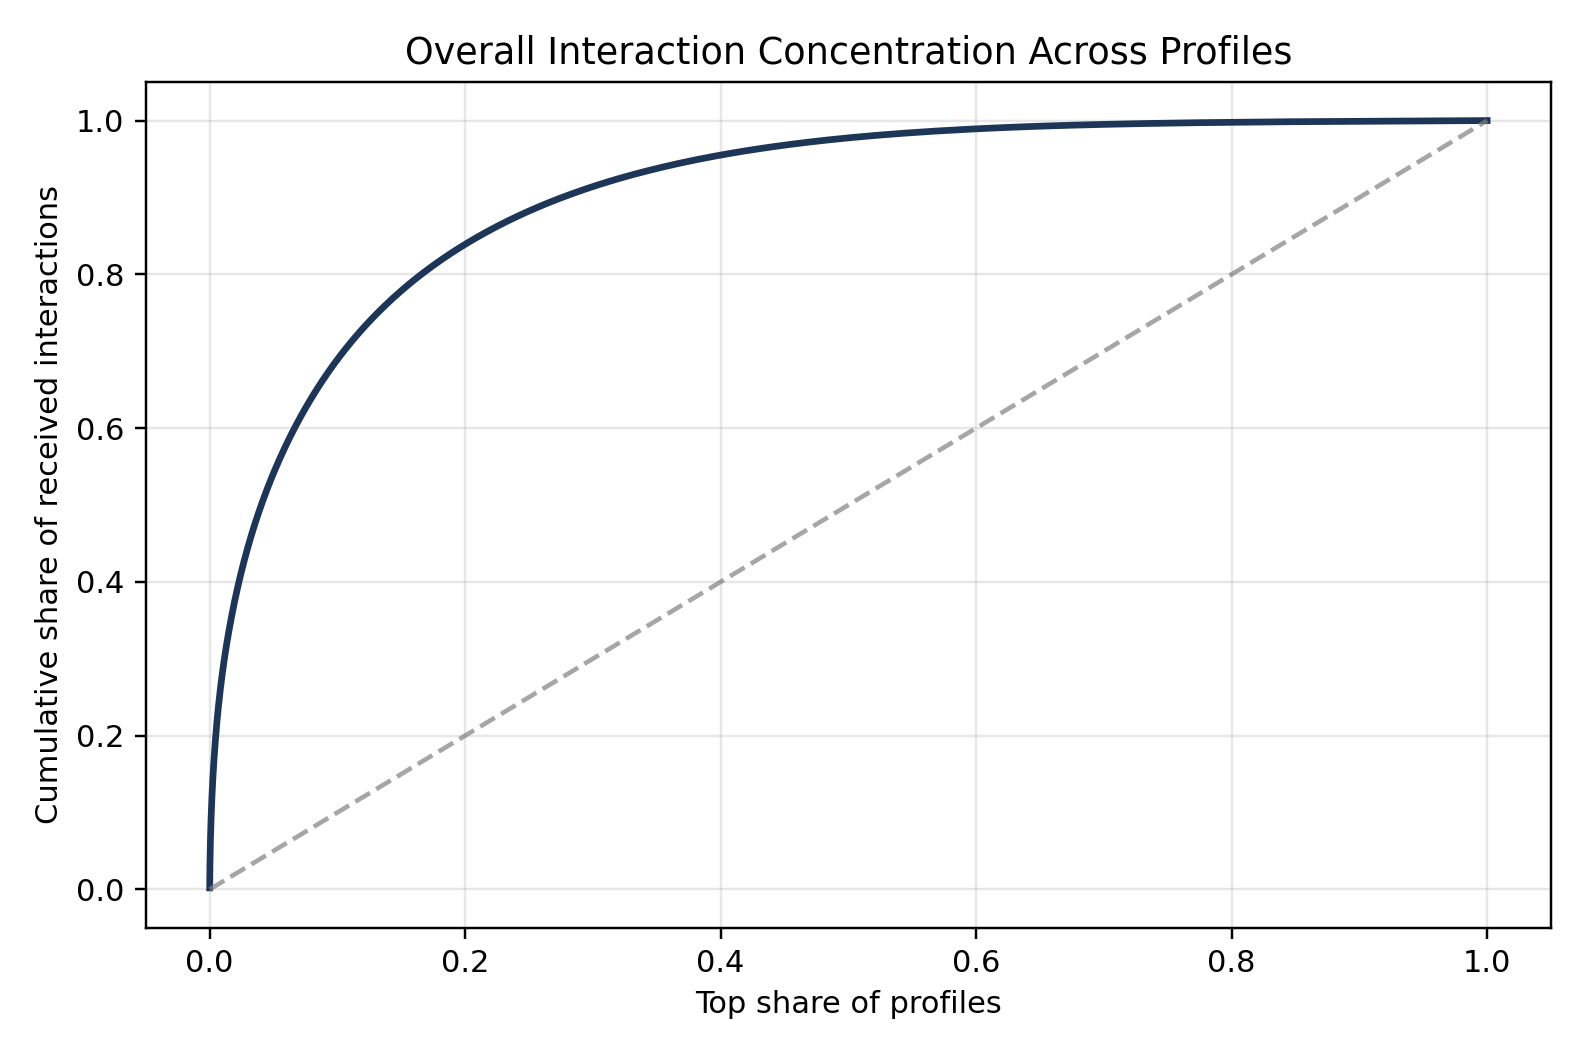

### profile_interaction_bucket_shares_full.png

Disjoint bucket shares for overall interaction.

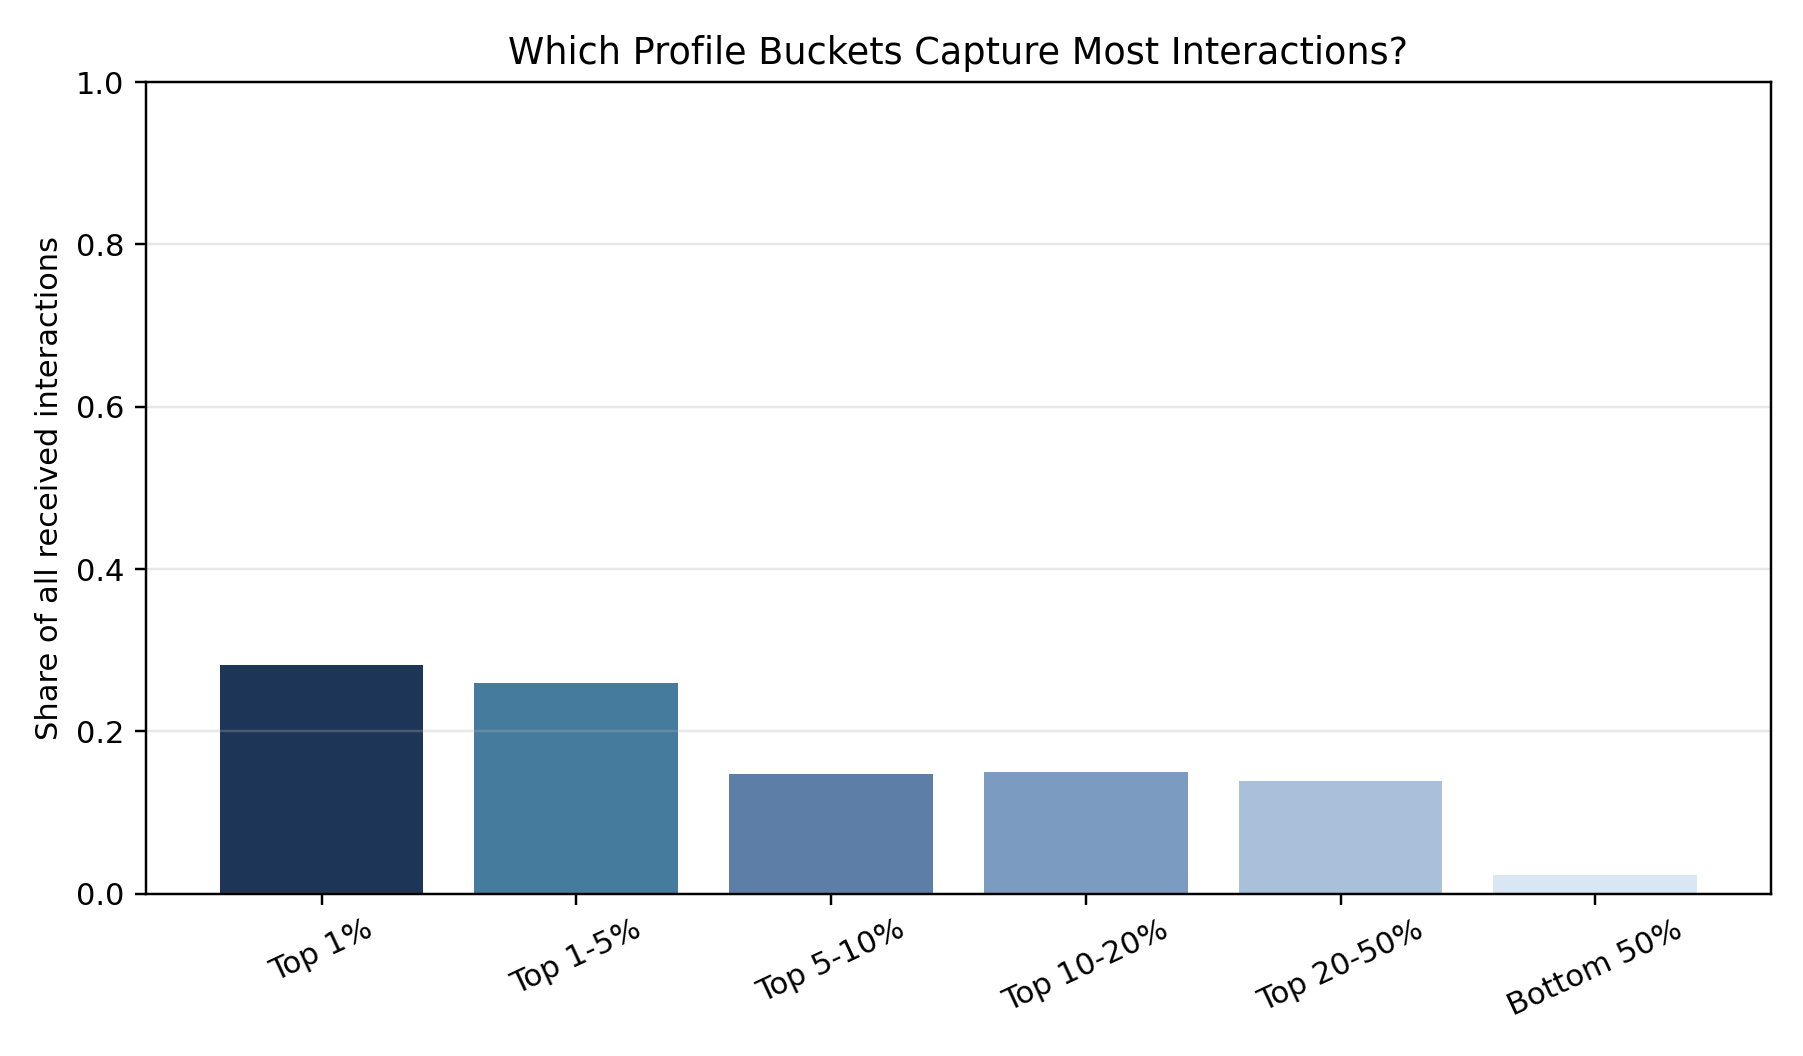

In [3]:
concentration_figures = [
    (
        "profile_high_low_rating_concentration_full.png",
        "Cumulative concentration of high and low ratings.",
    ),
    (
        "profile_rating_concentration_curves_full.png",
        "Separate concentration curves for high and low ratings.",
    ),
    (
        "profile_bucket_shares_full.png",
        "Disjoint bucket shares for high and low ratings.",
    ),
    (
        "profile_interaction_concentration_curve_full.png",
        "Overall interaction concentration on the profile side.",
    ),
    (
        "profile_interaction_bucket_shares_full.png",
        "Disjoint bucket shares for overall interaction.",
    ),
]

for filename, note in concentration_figures:
    display(Markdown(f"### {filename}\n\n{note}"))
    display(Image(filename=str(OUTPUT_FIGURES / filename)))


In [4]:
display(Markdown("### Profiles receiving the most high ratings"))
display(top_high.head(15))

display(Markdown("### Profiles receiving the most low ratings"))
display(top_low.head(15))

display(
    Markdown(
        f"""
        ## Application 1 Takeaways

        - The top **1%** of profiles receives **{all_summary['top_1pct_share']:.2%}** of all interactions.
        - The same top **1%** receives **{high_summary['top_1pct_share']:.2%}** of all high ratings.
        - Low ratings are concentrated too, but less sharply than high ratings.
        - This means that concentration is a general property of the profile side, not only a property of positive ratings.
        """
    )
)


### Profiles receiving the most high ratings

,profile_id,total_received,high_received,low_received,mean_rating,high_share_within_profile,low_share_within_profile,rank
0,606,33389,33384,0,9.9961,0.9999,0.0000,1
1,320,23649,21899,2,8.2968,0.9260,0.0001,2
2,228,23639,21791,778,9.5023,0.9218,0.0329,3
3,4963,21284,21283,0,9.9807,1.0000,0.0000,4
4,48,21387,21202,170,9.9232,0.9913,0.0079,5
5,1440,28398,18249,664,7.7906,0.6426,0.0234,6
6,44,18550,15384,3,8.2346,0.8293,0.0002,7
7,1477,16049,14094,1951,8.5463,0.8782,0.1216,8
8,8066,13485,13300,1,8.0644,0.9863,0.0001,9
9,220,13190,12801,0,7.9813,0.9705,0.0000,10


### Profiles receiving the most low ratings

,profile_id,total_received,high_received,low_received,mean_rating,high_share_within_profile,low_share_within_profile,rank
0,4478,11715,5,11689,1.0096,0.0004,0.9978,1
1,4412,12343,260,11437,2.3203,0.0211,0.9266,2
2,415,14335,450,9141,2.7911,0.0314,0.6377,3
3,188,9235,370,7673,2.2355,0.0401,0.8309,4
4,4920,18224,1083,6533,4.1138,0.0594,0.3585,5
5,3308,6534,126,6183,1.3447,0.0193,0.9463,6
6,215,6388,385,5226,2.1985,0.0603,0.8181,7
7,5216,5716,75,5085,2.4542,0.0131,0.8896,8
8,2503,4312,197,3963,1.5761,0.0457,0.9191,9
9,7590,3843,0,3834,1.0416,0.0000,0.9977,10



        ## Application 1 Takeaways

        - The top **1%** of profiles receives **28.23%** of all interactions.
        - The same top **1%** receives **43.75%** of all high ratings.
        - Low ratings are concentrated too, but less sharply than high ratings.
        - This means that concentration is a general property of the profile side, not only a property of positive ratings.
        

## Application 2 | Feature Alignment Across the Full Bucket Ladder

The next question is whether the concentration study and the popularity/prestige study tell a connected story.

We compare the exact profile buckets from the concentration analysis with the node-level features from the first study.


In [5]:
overlap_view = alignment_overlap.copy()
overlap_view["bucket"] = pd.Categorical(overlap_view["bucket"], categories=bucket_order, ordered=True)
overlap_view = overlap_view.sort_values("bucket")
display(overlap_view.round(4))

top_overlap = alignment_overlap.loc[alignment_overlap["bucket"] == "Top 1%"].iloc[0]
bottom_overlap = alignment_overlap.loc[alignment_overlap["bucket"] == "Bottom 50%"].iloc[0]

display(
    Markdown(
        f"""
        ### Exact-bucket overlap summary

        - Top 1% overlap: **{top_overlap['intersection_size']:,} shared profiles**, Jaccard **{top_overlap['jaccard_overlap']:.2%}**
        - Bottom 50% overlap: **{bottom_overlap['intersection_size']:,} shared profiles**, Jaccard **{bottom_overlap['jaccard_overlap']:.2%}**
        - Random-null expectation for the Top 1% overlap: **{top_overlap['expected_random_intersection']:.1f}** profiles
        """
    )
)


,bucket,interaction_bucket_size,high_bucket_size,intersection_size,union_size,jaccard_overlap,share_of_interaction_bucket_overlapping,share_of_high_bucket_overlapping,population_size,expected_random_intersection,expected_random_overlap_share_interaction,expected_random_overlap_share_high,expected_random_jaccard,exact_hypergeom_p_value,exact_hypergeom_log10_p_value,simulation_draws,simulated_mean_intersection,simulated_std_intersection,simulated_max_intersection,simulated_p_ge_observed,zscore_vs_random
0,Top 1%,1687,1687,1029,2345,0.4388,0.6100,0.6100,168792,16.8608,0.0100,0.0100,0.0050,0.0000,"-1,747.3655",20000,16.8240,4.0494,37,0.0000,248.9787
1,Top 1-5%,6752,6752,2849,10655,0.2674,0.4219,0.4219,168792,270.0928,0.0400,0.0400,0.0204,0.0000,"-2,326.4585",20000,270.3780,15.7954,340,0.0000,163.4585
2,Top 5-10%,8440,8440,1942,14938,0.1300,0.2301,0.2301,168792,422.0200,0.0500,0.0500,0.0256,0.0000,-766.3070,20000,422.0570,19.5920,503,0.0000,77.8839
3,Top 10-20%,16879,16879,4899,28859,0.1698,0.2902,0.2902,168792,"1,687.8800",0.1000,0.1000,0.0526,0.0000,"-1,208.8440",20000,"1,688.3646",36.9419,1844,0.0000,86.8443
4,Top 20-50%,50638,50638,27605,73671,0.3747,0.5451,0.5451,168792,"15,191.5200",0.3000,0.3000,0.1765,0.0000,"-4,314.8105",20000,"15,190.1916",86.0076,15497,0.0000,143.8782
5,Bottom 50%,84396,84396,69489,99303,0.6998,0.8234,0.8234,168792,"42,198.0000",0.5000,0.5000,0.3333,0.0000,"-16,635.1574",20000,"42,196.3746",102.7949,42613,0.0000,265.7065



        ### Exact-bucket overlap summary

        - Top 1% overlap: **1,029 shared profiles**, Jaccard **43.88%**
        - Bottom 50% overlap: **69,489 shared profiles**, Jaccard **69.98%**
        - Random-null expectation for the Top 1% overlap: **16.9** profiles
        

### profile_feature_alignment_heatmap_full.png

Point-biserial correlations between Study 1 features and exact bucket membership.

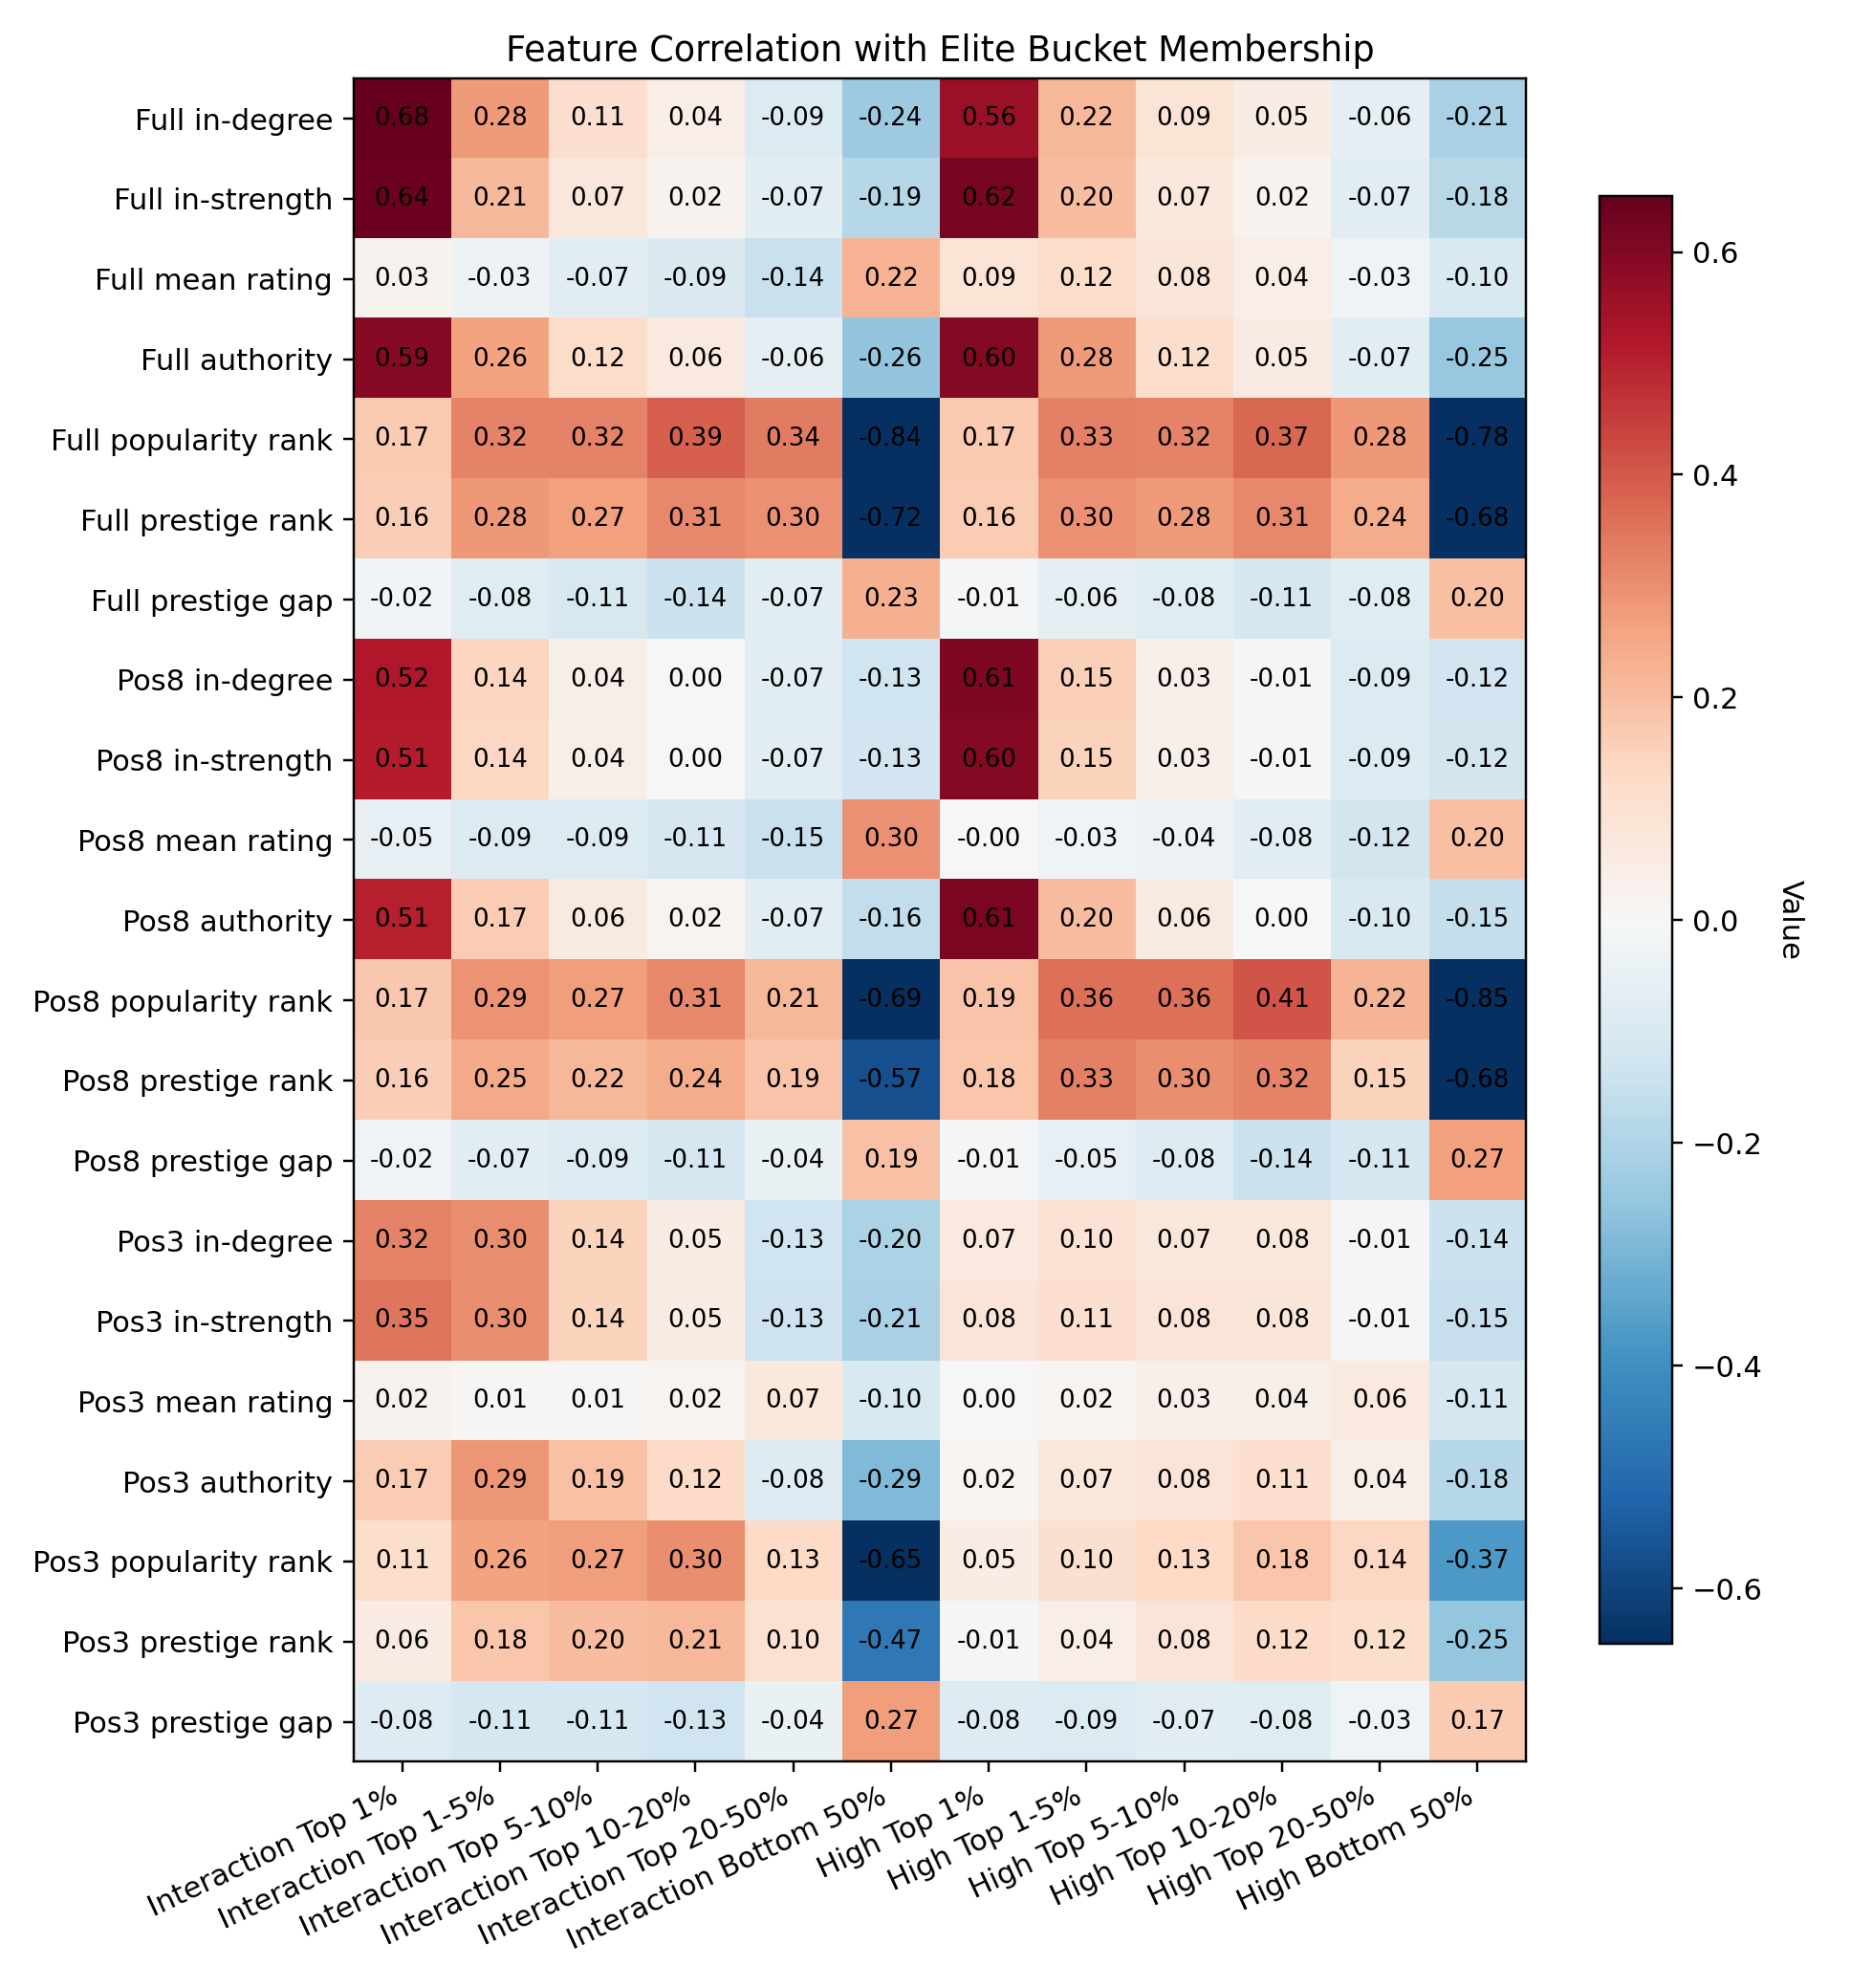

### profile_feature_alignment_zscore_heatmap_full.png

Standardized feature lift inside each exact bucket.

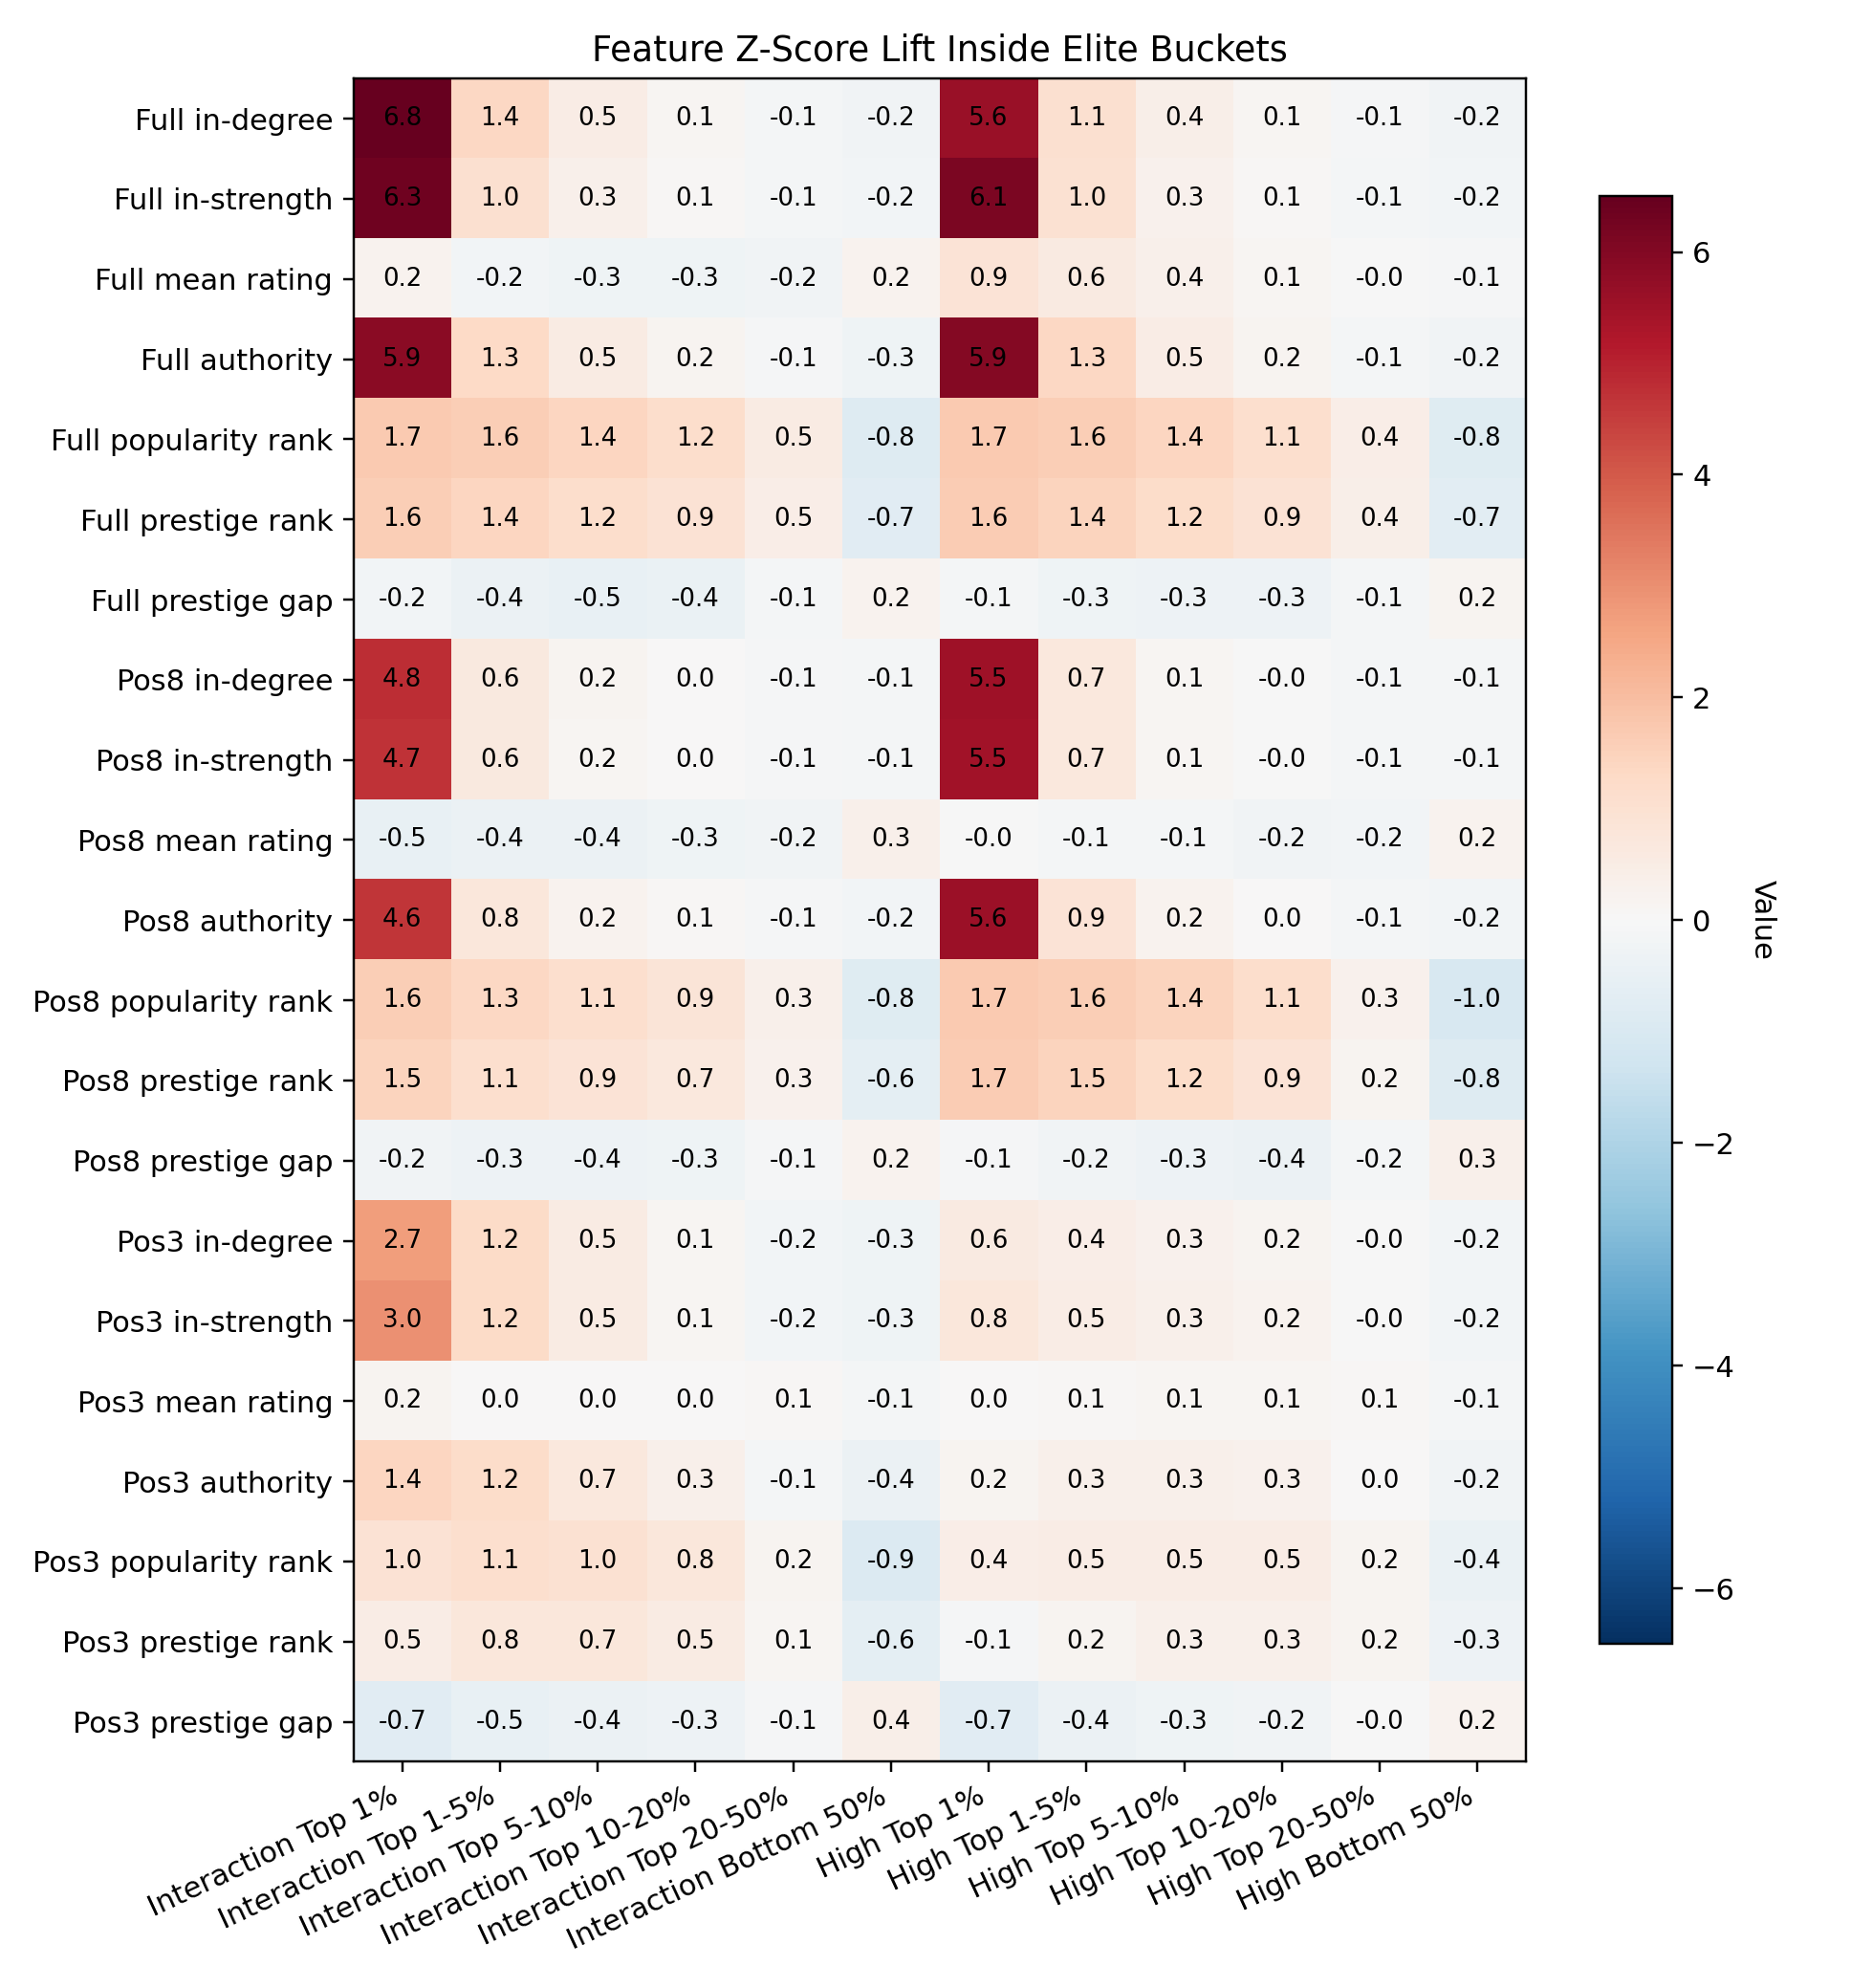

### profile_feature_alignment_consistency_full.png

Class-level alignment across ALL, POS8, and POS3 layers.

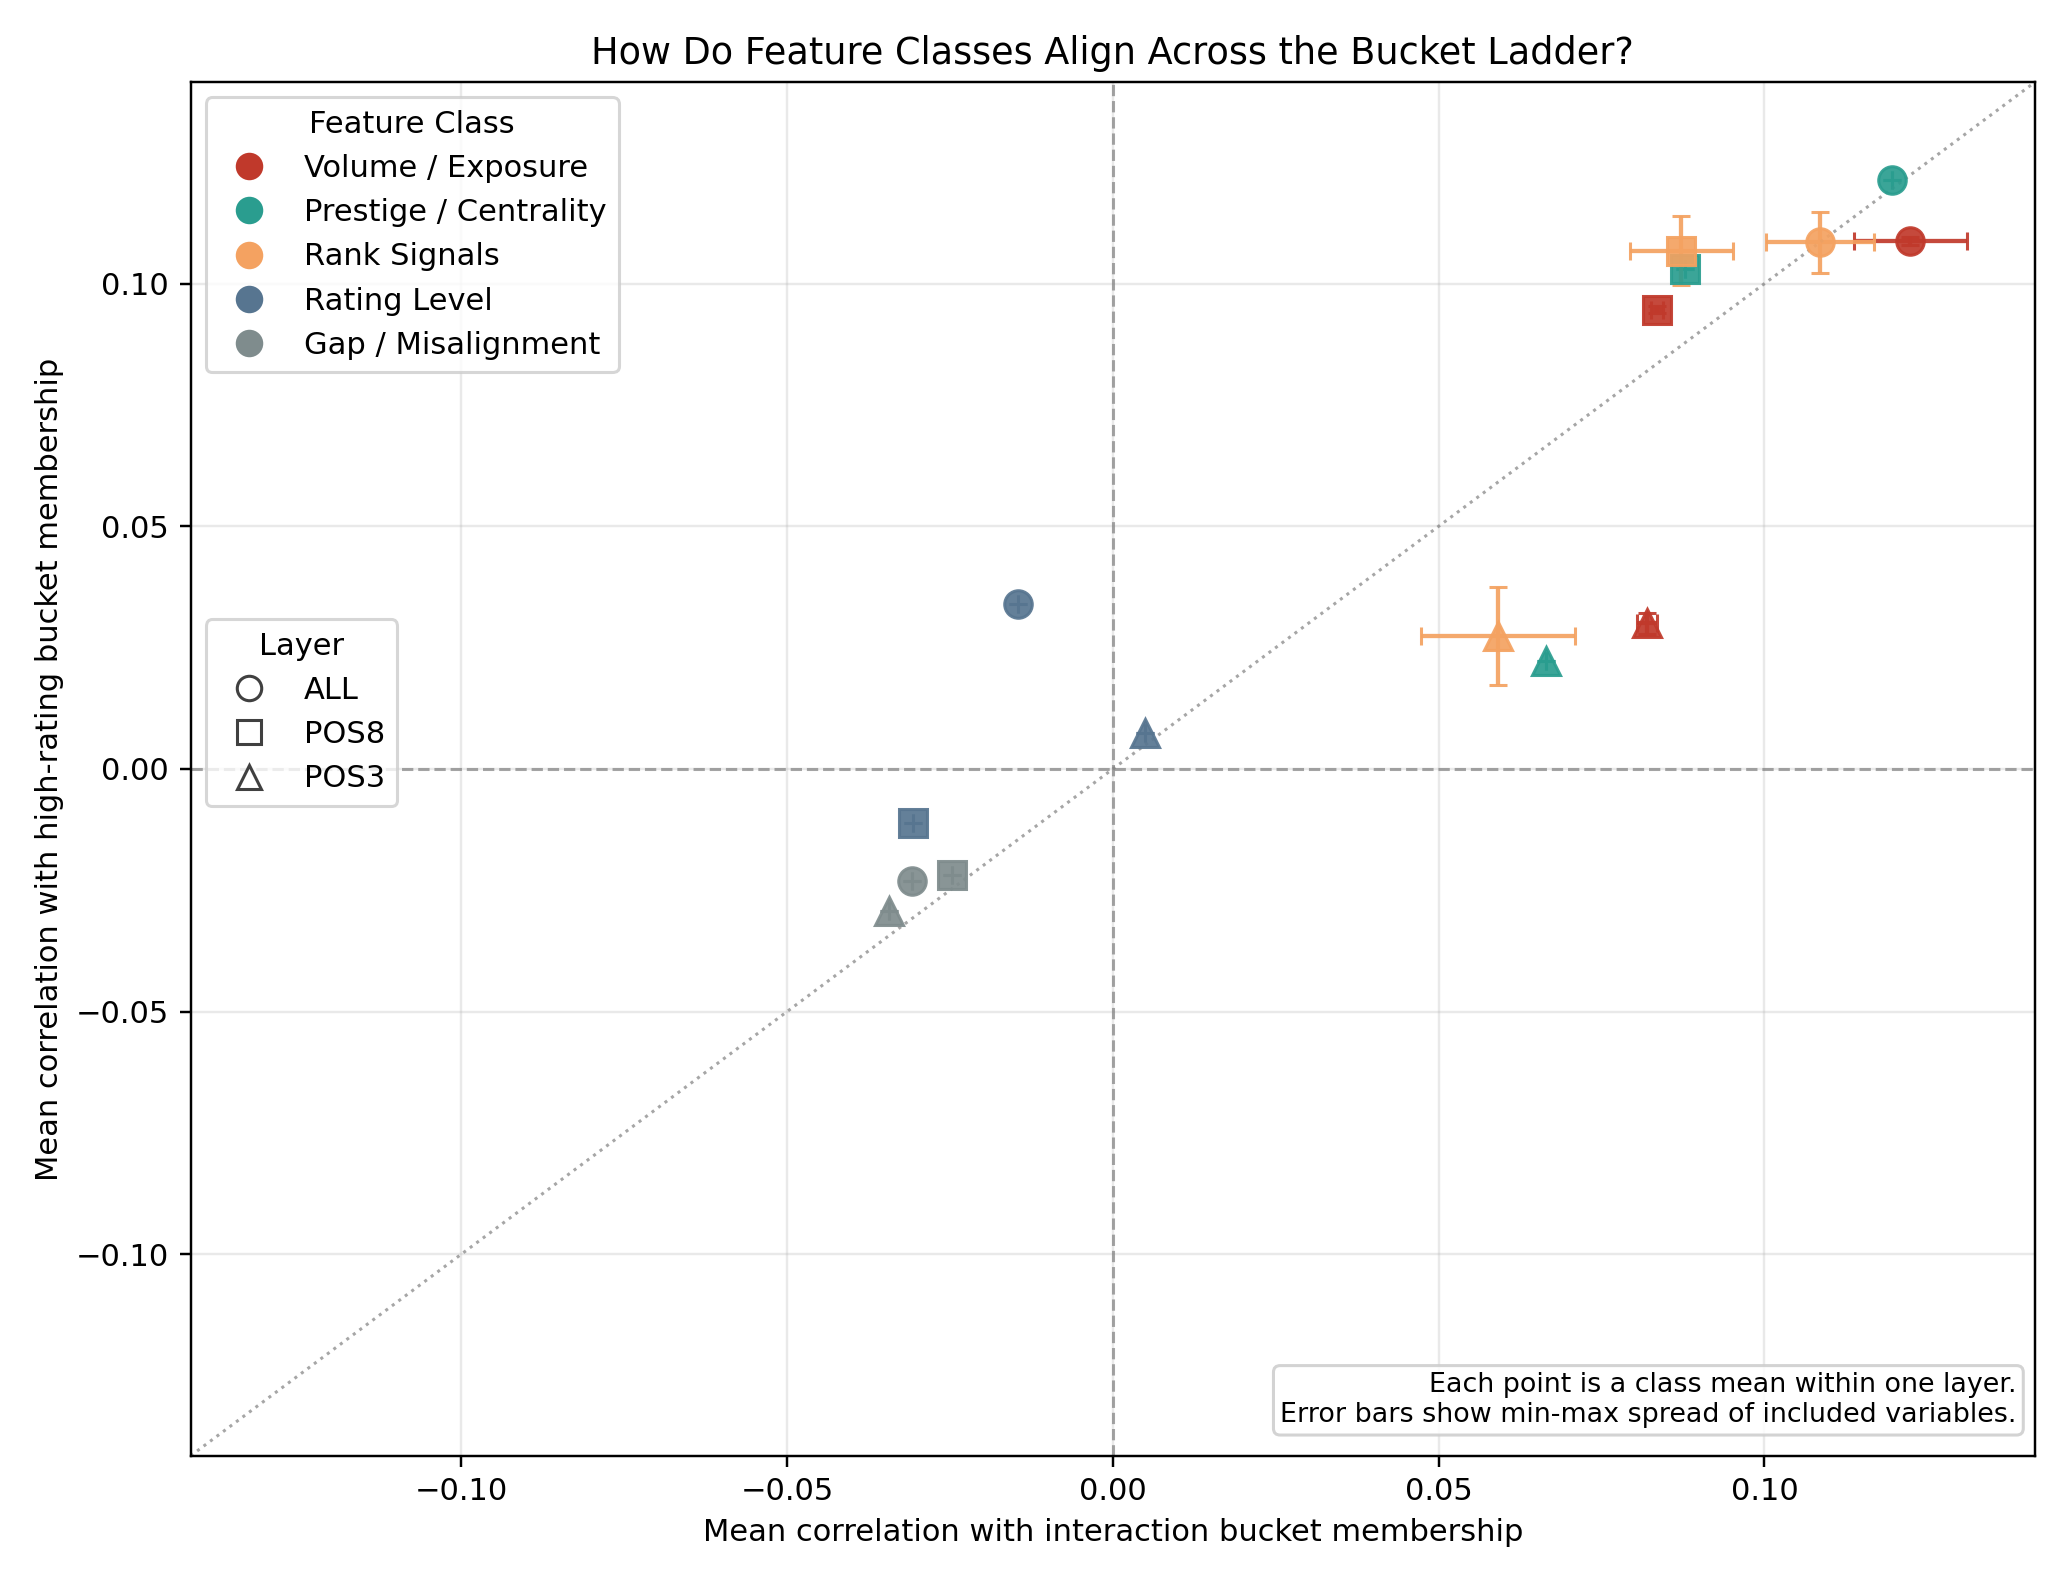

In [6]:
alignment_figures = [
    (
        "profile_feature_alignment_heatmap_full.png",
        "Point-biserial correlations between Study 1 features and exact bucket membership.",
    ),
    (
        "profile_feature_alignment_zscore_heatmap_full.png",
        "Standardized feature lift inside each exact bucket.",
    ),
    (
        "profile_feature_alignment_consistency_full.png",
        "Class-level alignment across ALL, POS8, and POS3 layers.",
    ),
]

for filename, note in alignment_figures:
    display(Markdown(f"### {filename}\n\n{note}"))
    display(Image(filename=str(OUTPUT_FIGURES / filename)))


In [7]:
class_view = alignment_feature_classes[
    [
        "class_label",
        "layer_label",
        "feature_count",
        "interaction_mean_corr",
        "high_mean_corr",
        "included_features",
    ]
].sort_values(["class_label", "layer_label"])

positive_signals = alignment_summary[
    (alignment_summary["interaction_mean_corr"] > 0) & (alignment_summary["high_mean_corr"] > 0)
].sort_values("shared_signal_strength", ascending=False)

display(Markdown("### Class summary"))
display(class_view.round(3))

display(Markdown("### Strongest shared positive signals"))
display(
    positive_signals[
        [
            "feature_label",
            "interaction_mean_corr",
            "high_mean_corr",
            "shared_signal_strength",
        ]
    ].head(8).round(3)
)


### Class summary

,class_label,layer_label,feature_count,interaction_mean_corr,high_mean_corr,included_features
12,Gap / Misalignment,ALL,1,-0.0310,-0.0230,Full prestige gap
14,Gap / Misalignment,POS3,1,-0.0340,-0.0290,Pos3 prestige gap
13,Gap / Misalignment,POS8,1,-0.0250,-0.0220,Pos8 prestige gap
3,Prestige / Centrality,ALL,1,0.1200,0.1210,Full authority
5,Prestige / Centrality,POS3,1,0.0660,0.0220,Pos3 authority
4,Prestige / Centrality,POS8,1,0.0880,0.1030,Pos8 authority
6,Rank Signals,ALL,2,0.1090,0.1090,Full popularity rank; Full prestige rank
8,Rank Signals,POS3,2,0.0590,0.0270,Pos3 popularity rank; Pos3 prestige rank
7,Rank Signals,POS8,2,0.0870,0.1070,Pos8 popularity rank; Pos8 prestige rank
9,Rating Level,ALL,1,-0.0150,0.0340,Full mean rating


### Strongest shared positive signals

,feature_label,interaction_mean_corr,high_mean_corr,shared_signal_strength
0,Full authority,0.1200,0.1210,0.1200
1,Full popularity rank,0.1170,0.1150,0.1150
2,Full in-strength,0.1140,0.1100,0.1100
3,Full in-degree,0.1310,0.1080,0.1080
4,Full prestige rank,0.1000,0.1020,0.1000
5,Pos8 popularity rank,0.0950,0.1140,0.0950
6,Pos8 authority,0.0880,0.1030,0.0880
7,Pos8 in-degree,0.0840,0.0950,0.0840


In [8]:
display(
    Markdown(
        f"""
        ## Application 2 Takeaways

        - The alignment is strongest at the extremes of the ranking, especially in the Top 1% and Bottom 50% buckets.
        - The observed Top 1% overlap (**{top_overlap['intersection_size']:,}** profiles) is far larger than the fixed-size random expectation (**{top_overlap['expected_random_intersection']:.1f}**).
        - The most stable shared signals come from degree, strength, authority, and rank-based variables.
        """
    )
)



        ## Application 2 Takeaways

        - The alignment is strongest at the extremes of the ranking, especially in the Top 1% and Bottom 50% buckets.
        - The observed Top 1% overlap (**1,029** profiles) is far larger than the fixed-size random expectation (**16.9**).
        - The most stable shared signals come from degree, strength, authority, and rank-based variables.
        

## Next

The final notebook gathers the last figures and reference values:

- collect the final figures
- show the reference values
- keep the final outputs in one place
